# BEE2041 Data Science in Economics Empirical Project Analysis

In this Notebook I will be completing the webscraping, data cleaning, data analysis and generation of figures for my empirical project

## Installing and importing libraries

In [1]:
# install the necessary libraries

!pip install requests beautifulsoup4 pandas matplotlib seaborn scipy --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# import the necessary libraries into the Jupyter notebook
    # os: interacts with my operating system
    # time: used for time related functions
    # numpy: python library for numerical operations
    # pandas: used for data manipulation and analysis
    # scipy: statistical computing
    # matplotlib: low-level plotting and figure creation
    # seaborn: high-level statistical visualisations
    # requests: downloads the HTML of a page
    # BeautifulSoup: parses and navigates the HTML structure

import os
import time

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup

In [3]:
# Create folders in my directory to save CSVs or figures to later

os.makedirs("data/raw", exist_ok = True)
os.makedirs("data/processed", exist_ok = True)
os.makedirs("figures", exist_ok = True)

## Attempted approach: Scraping World Athletics

My first attempt to scrape data for my investigation was the scrape directly from the [World Athletics](worldathletics.org) website. This failed because the website loads its data dynamically, which means the data is not available in the raw HTML that requests.get() can access. I could have used Selenium to scrape the World Athletics website but this would prove very complicated.

In [4]:
# This is the URL of the webpage I'll be scraping for data
url = "https://worldathletics.org/stats-zone"

# # Send a GET request to the WorldAthletics website; this is grabbing data from the website
# returns a response object which contains the HTML content of the page as a string (response.text) and the HTTP status code (tells me whether the request worked or not)
response = requests.get(url)

# Covert the raw HTML into a structured object using BeautifulSoup
soup = BeautifulSoup(response.text, "html.parser")

# Extracting the data
# rows = soup.find_all("pre")[0].text.split("\n")
# This line returns an error "list index out of range", which means I am trying to access an item in a position that does not exist.

print(soup.find_all("pre"))
# returns an empty list, meaning there are no <pre> tags; there is no data in the HTML requests.get() downloaded.

[]


When I press CTRL+U while on the WorldAthletics page in my browser, this shows the raw HTML of the website. If I search within this raw HTML for a known athlete's name (for example Usain Bolt), it returns nothing. This means the data is not in the HTML and the page is loaded dynamically. JavaScript is the most common reason for this. 
A webpage being loaded dynamically means the data arrives separately from the HTML. The problem with trying to scrape using requests.get() is it only grabs the HTML, which is empty, and stops there so it never sees the data.

## I'm now going to scrape the [Alltime Athletics](https://www.alltime-athletics.com/) website instead of the World Athletics website.

When using the same (CTRL+U) method to investigate the alltime athletics website, I can see athlete names within the raw HTML. This means the webpage is statically loaded and requests.get() will be able to see all the data.

## Webscraping

Data scraped from https://www.alltime-athletics.com/ (Peter Larsson, 1997-2026) for academic research purposes only as part of BEE2041 Empirical Project. This data is not being reproduced; it is solely for statistical analysis of athletic performance trends

### Scraping for female data

I'm going to begin by scraping only the female data in the:
* Sprint events
    * 100m
    * 200m
    * 400m
* Endurance events
    * 1500m
    * 5000m
    * 10000m

I'm going to start by only scraping one event (100m) to ensure my logic is sound

In [5]:
# Assigning the URL of the webpage I'll be scraping to a variable

url_100W = "https://www.alltime-athletics.com/w_100ok.htm"

In [6]:
# Send a HTTP GET request to Alltime Athletics

response_100W = requests.get(url_100W)

In [7]:
# Converting the raw HTML to a structured, searchable object

soup_100W = BeautifulSoup(response_100W.text, "html.parser")

In [8]:
# Creating usable data rows

pre_tag_100W = soup_100W.find("pre")

rows_100W = pre_tag_100W.text.split("\n")

In [9]:
# How many rows are there and what do they look like?

print(len(rows_100W))
print(rows_100W[:5])

3437
['', '        1      10.54      +0.9    Elaine Thompson-Herah          JAM     28.06.92    1      Eugene                     21.08.2021', '        2      10.60      +1.7    Shelly-Ann Fraser-Pryce        JAM     27.12.86    1rA    Lausanne                   26.08.2021', '        3      10.61      +1.2    Florence Griffith-Joyner       USA     21.12.59    1      Indianapolis               17.07.1988', '        3      10.61      -0.6    Elaine Thompson-Herah          JAM     28.06.92    1      Tokyo                      31.07.2021']


In [10]:
# Converting rows of data into a DataFrame

data_100W = []

for row in rows_100W:
    # Split the row by spaces
    parts = row.split()
    # Skip rows without enough elements (I have 9 variables) or header rows
    if len(parts) < 9 or not parts[0].isdigit():
        continue
    try:
        # the columns I know the index of for certain
        rank = parts[0]
        mark = parts[1]
        year = parts[-1]
        # Athlete is everything between columns 3 and 5
        athlete = " ".join(parts[3:-5])
        
        data_100W.append([rank, mark, athlete, year])
    # Skip rows which have invalid data types or missing list elements and move on
    except (ValueError, IndexError):
        continue

df_100W = pd.DataFrame(data_100W, columns = ["Rank", "Time", "Athlete", "Year"])

In [11]:
# Checking the structure of the DataFrame

print(df_100W.info())

<class 'pandas.DataFrame'>
RangeIndex: 3434 entries, 0 to 3433
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Rank     3434 non-null   str  
 1   Time     3434 non-null   str  
 2   Athlete  3434 non-null   str  
 3   Year     3434 non-null   str  
dtypes: str(4)
memory usage: 107.4 KB
None


In [12]:
# What does the DataFrame look like?

df_100W.head()

,Rank,Time,Athlete,Year
0,1,10.54,Elaine Thompson-Herah,21.08.2021
1,2,10.60,Shelly-Ann Fraser-Pryce,26.08.2021
2,3,10.61,Florence Griffith-Joyner,17.07.1988
3,3,10.61,Elaine Thompson-Herah,31.07.2021
4,3,10.61,Melissa Jefferson-Wooden,14.09.2025


In [13]:
# Checking for lost data: How many rows did I lose?

# Count the number of valid rows on AllTimeAthletics
valid_rows_100W = []

for row in rows_100W:
    parts = row.split()
    if len(parts) >= 9 and parts[0].isdigit():
        valid_rows_100W.append(row)

print("Estimated valid rows:", len(valid_rows_100W))

# Compare rows before and after parsing:
print("Valid rows before parsing:", len(valid_rows_100W))
print("Successfully parsed rows:", len(data_100W))

Estimated valid rows: 3434
Valid rows before parsing: 3434
Successfully parsed rows: 3434


In [14]:
# Adding an event and gender column to be able to differentiate the rows later when I combine different events and genders into one CSV file.
df_100W["Event"] = "100m"
df_100W["Gender"] = "Female"

# Check the columns were added successfully
df_100W.head()

,Rank,Time,Athlete,Year,Event,Gender
0,1,10.54,Elaine Thompson-Herah,21.08.2021,100m,Female
1,2,10.60,Shelly-Ann Fraser-Pryce,26.08.2021,100m,Female
2,3,10.61,Florence Griffith-Joyner,17.07.1988,100m,Female
3,3,10.61,Elaine Thompson-Herah,31.07.2021,100m,Female
4,3,10.61,Melissa Jefferson-Wooden,14.09.2025,100m,Female


Now I know the webscraping logic works for 100m data, I'll scrape all the remaining events at the same time (200m, 400m, 1500m, 5000m and 10,000m) to avoid repetition.

In [15]:
# Create a dictionary of all required events

eventsW = {
    "200m": "https://www.alltime-athletics.com/w_200ok.htm",
    "400m": "https://www.alltime-athletics.com/w_400ok.htm",
    "1500m": "https://www.alltime-athletics.com/w_1500ok.htm",
    "5000m": "https://www.alltime-athletics.com/w_5000ok.htm",
    "10000m": "https://www.alltime-athletics.com/w_10kok.htm"
}

In [16]:
# Scraping each website in the dictionary for the data
# The same steps as before just all in one function and with the code returning its progress

dfs_W = []
for event_name, url in eventsW.items():
    print("Scraping " + event_name + "...")

    headers = {"User-Agent": "Mozilla/5.0"}
    # wait for maximum 15 seconds for the website to respond before returning an error
    response = requests.get(url, headers = headers, timeout = 15)
    soup = BeautifulSoup(response.text, "html.parser")
    pre = soup.find("pre")

    if pre is None:
        print("No data found for " + event_name + ", skipping")
        continue

    rows = pre.text.split("\n")
    data = []

    for row in rows:
        parts = row.split()
        if len(parts) < 9 or not parts[0].isdigit():
            continue
        try:
            rank = parts[0]
            mark = parts[1]
            year = parts[-1]
            athlete = " ".join(parts[3:-5])
            data.append([rank, mark, athlete, year])
        except (ValueError, IndexError):
            continue
    df_eventsW = pd.DataFrame(data, columns = ["Rank", "Time", "Athlete", "Year"])
    df_eventsW["Event"] = event_name
    df_eventsW["Gender"] = "Female"

    print(" " + str(len(df_eventsW)) + " rows scraped")
    dfs_W.append(df_eventsW)
    # Wait 2 seconds between requests to avoid overwhelming the website
    time.sleep(2)

dfW_all = pd.concat(dfs_W, ignore_index = True)
print("\nTotal rows: " + str(len(dfW_all)))

Scraping 200m...
 2743 rows scraped
Scraping 400m...
 4120 rows scraped
Scraping 1500m...
 3502 rows scraped
Scraping 5000m...
 5532 rows scraped
Scraping 10000m...
 2665 rows scraped

Total rows: 18562


In [17]:
# Check the structure of the result

print(dfW_all.info())

<class 'pandas.DataFrame'>
RangeIndex: 18562 entries, 0 to 18561
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Rank     18562 non-null  str  
 1   Time     18562 non-null  str  
 2   Athlete  18562 non-null  str  
 3   Year     18562 non-null  str  
 4   Event    18562 non-null  str  
 5   Gender   18562 non-null  str  
dtypes: str(6)
memory usage: 870.2 KB
None


In [18]:
# Does the DataFrame look how I expect?

dfW_all.head()

,Rank,Time,Athlete,Year,Event,Gender
0,1,21.34,Florence Griffith-Joyner,29.09.1988,200m,Female
1,2,21.41,Shericka Jackson,25.08.2023,200m,Female
2,3,21.45,Shericka Jackson,21.07.2022,200m,Female
3,4,21.48,Shericka Jackson,08.09.2023,200m,Female
4,5,21.53,Elaine Thompson-Herah,03.08.2021,200m,Female


In [19]:
# Combine all female event data into one large DataFrame
# I should have (3408 + 18828 = 22,236) entries

dfW_all = pd.concat([dfW_all, df_100W], ignore_index = True)

print(dfW_all.info())

<class 'pandas.DataFrame'>
RangeIndex: 21996 entries, 0 to 21995
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Rank     21996 non-null  str  
 1   Time     21996 non-null  str  
 2   Athlete  21996 non-null  str  
 3   Year     21996 non-null  str  
 4   Event    21996 non-null  str  
 5   Gender   21996 non-null  str  
dtypes: str(6)
memory usage: 1.0 MB
None


In [20]:
# Save the raw female data to a CSV before combining

dfW_all.to_csv("data/raw/female_athletics_raw.csv", index = False)

### Scraping for male data: 

Next, I'm going to scrape the mens' data in the:
* Sprint events
    * 100m
    * 200m
    * 400m
* Endurance events
    * 1500m
    * 5000m
    * 10000m

In [21]:
# Create a dictionary of all event URLs

eventsM = {
    "100m": "https://www.alltime-athletics.com/m_100ok.htm",
    "200m": "https://www.alltime-athletics.com/m_200ok.htm",
    "400m": "https://www.alltime-athletics.com/m_400ok.htm",
    "1500m": "https://www.alltime-athletics.com/m_1500ok.htm",
    "5000m": "https://www.alltime-athletics.com/m_5000ok.htm",
    "10000m": "https://www.alltime-athletics.com/m_10kok.htm"
}

In [22]:
# Scraping each URL for the data

dfs_M = []
for event_name, url in eventsM.items():
    print("Scraping " + event_name + "...")

    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers = headers, timeout = 15)
    soup = BeautifulSoup(response.text, "html.parser")
    pre = soup.find("pre")

    if pre is None:
        print("No data found for " + event_name + ", skipping")
        continue

    rows = pre.text.split("\n")
    data = []

    for row in rows:
        parts = row.split()
        if len(parts) < 9 or not parts[0].isdigit():
            continue
        try:
            rank = parts[0]
            mark = parts[1]
            year = parts[-1]
            athlete = " ".join(parts[3:-5])
            data.append([rank, mark, athlete, year])
        except (ValueError, IndexError):
            continue
    df_eventsM = pd.DataFrame(data, columns = ["Rank", "Time", "Athlete", "Year"])
    df_eventsM["Event"] = event_name
    df_eventsM["Gender"] = "Male"

    print(" " + str(len(df_eventsM)) + " rows scraped")
    dfs_M.append(df_eventsM)
    # Wait 2 seconds between requests to avoid overwhelming the website
    time.sleep(2)

dfM_all = pd.concat(dfs_M, ignore_index = True)
print("\nTotal rows: " + str(len(dfM_all)))

Scraping 100m...
 4885 rows scraped
Scraping 200m...
 5054 rows scraped
Scraping 400m...
 5100 rows scraped
Scraping 1500m...
 11681 rows scraped
Scraping 5000m...
 9582 rows scraped
Scraping 10000m...
 10936 rows scraped

Total rows: 47238


In [23]:
dfM_all.head()

,Rank,Time,Athlete,Year,Event,Gender
0,1,9.58,Usain Bolt,16.08.2009,100m,Male
1,2,9.63,Usain Bolt,05.08.2012,100m,Male
2,3,9.69,Usain Bolt,16.08.2008,100m,Male
3,3,9.69,Tyson Gay,20.09.2009,100m,Male
4,3,9.69,Yohan Blake,23.08.2012,100m,Male


In [24]:
# Save the raw male data to a CSV before combining

dfM_all.to_csv("data/raw/male_athletics_raw.csv", index = False)

### Combining male and female raw data into one CSV

In [25]:
# Load raw female data

df_female = pd.read_csv("data/raw/female_athletics_raw.csv")
df_female.info()

<class 'pandas.DataFrame'>
RangeIndex: 21996 entries, 0 to 21995
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Rank     21996 non-null  int64
 1   Time     21996 non-null  str  
 2   Athlete  21996 non-null  str  
 3   Year     21996 non-null  str  
 4   Event    21996 non-null  str  
 5   Gender   21996 non-null  str  
dtypes: int64(1), str(5)
memory usage: 1.0 MB


In [26]:
# Create a copy of df_female

df_female_copy = df_female.copy()

In [27]:
# Load raw male data

df_male = pd.read_csv("data/raw/male_athletics_raw.csv")
df_male.info()

<class 'pandas.DataFrame'>
RangeIndex: 47238 entries, 0 to 47237
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Rank     47238 non-null  int64
 1   Time     47238 non-null  str  
 2   Athlete  47238 non-null  str  
 3   Year     47238 non-null  str  
 4   Event    47238 non-null  str  
 5   Gender   47238 non-null  str  
dtypes: int64(1), str(5)
memory usage: 2.2 MB


In [28]:
# Create a copy of df_male

df_male_copy = df_male.copy()

In [29]:
# Combine both the female and male data

df_all = pd.concat([df_female_copy, df_male_copy], ignore_index = True)

In [30]:
# Should return (21996 + 47237 = 69233) entries

df_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 69234 entries, 0 to 69233
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Rank     69234 non-null  int64
 1   Time     69234 non-null  str  
 2   Athlete  69234 non-null  str  
 3   Year     69234 non-null  str  
 4   Event    69234 non-null  str  
 5   Gender   69234 non-null  str  
dtypes: int64(1), str(5)
memory usage: 3.2 MB


In [31]:
# Save the complete DataFrame to CSV in the raw folder

df_all.to_csv("data/raw/athletics_raw_complete.csv", index = False)

## Cleaning the data

In [32]:
# Load the raw data CSV

df_raw = pd.read_csv("data/raw/athletics_raw_complete.csv")
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 69234 entries, 0 to 69233
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Rank     69234 non-null  int64
 1   Time     69234 non-null  str  
 2   Athlete  69234 non-null  str  
 3   Year     69234 non-null  str  
 4   Event    69234 non-null  str  
 5   Gender   69234 non-null  str  
dtypes: int64(1), str(5)
memory usage: 3.2 MB


In [33]:
# Create a copy of the original DataFrame

df_clean = df_raw.copy()

### Missing values

I'm going to check for any rows in the dataset with missing data.

In [34]:
# Check for any missing values or invalid rows

df_clean.isnull().sum()

Rank       0
Time       0
Athlete    0
Year       0
Event      0
Gender     0
dtype: int64

There is no missing data, so I don't need to drop or fill anything.

### Duplicated Data

Ensure there are no duplicated rows in my dataset, so that once I begin analysing the data no performances are being counted more than once.  
A row is considered a duplicate if **every** columns matches exactly. Dropping duplicated rows does not mean if an athlete's name appears more than once in the dataset (for example), subsequent rows with that name will be dropped. Each column in the same row needs to match exactly for the row to be dropped.

In [35]:
# investigating if there are any duplicated data rows

df_clean.duplicated().sum()

np.int64(117)

In [36]:
# Remove the duplicates

df_clean.drop_duplicates(inplace = True)
print(df_clean.duplicated().sum())
df_clean.info()

0
<class 'pandas.DataFrame'>
Index: 69117 entries, 0 to 69233
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Rank     69117 non-null  int64
 1   Time     69117 non-null  str  
 2   Athlete  69117 non-null  str  
 3   Year     69117 non-null  str  
 4   Event    69117 non-null  str  
 5   Gender   69117 non-null  str  
dtypes: int64(1), str(5)
memory usage: 3.7 MB


In [37]:
# The after dropping the duplicated rows the DataFrame has kept the original index values.
# Reset the index for cleaner data.

df_clean = df_clean.reset_index(drop = True)
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 69117 entries, 0 to 69116
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Rank     69117 non-null  int64
 1   Time     69117 non-null  str  
 2   Athlete  69117 non-null  str  
 3   Year     69117 non-null  str  
 4   Event    69117 non-null  str  
 5   Gender   69117 non-null  str  
dtypes: int64(1), str(5)
memory usage: 3.2 MB


### Convert Data Types

I need to convert data types within the DataFrame, specifically the Time and Year columns.  
Time is complicated because some of the time values also contain letters to account for wind readings or rankings. So for each time value I need to remove everything which is not a number, decimal point or colon (to account for times in minutes). Then, since sprint events are measured in seconds but endurance events are measured in minutes and seconds, I need to convert endurance event times into seconds before the data type can be converted to float.

In [38]:
# Convert data types within the DataFrame

# Some time values have letters as well (either from wind readings or rankings). 
# For each time value: remove everything that isn't a number, decimal point or colon
df_clean["Time"] = df_clean["Time"].str.extract(r"(\d+:\d+\.\d+|\d+\.\d+)")

# Time values for endurance events will be in minutes; these need converting into seconds before I can convert the data type
def convert_to_seconds(time):
    if ":" in time:
        minutes, seconds = time.split(":")
        return float(minutes) * 60 + float(seconds)
    else:
        return float(time)

df_clean["Time Seconds"] = df_clean["Time"].apply(convert_to_seconds)

Values in the year column are formatted as (e.g.) 21.08.2021. I need to clean the dates to only include the year.

In [39]:
# Extract the 4-digit year from the end of the string and overwrite the column with that value
df_clean["Year"] = df_clean["Year"].str.extract(r"(\d{4})$")
# Then convert to integer
df_clean["Year"] = df_clean["Year"].astype(int)

# Check this was successful
print(df_clean.dtypes)

Rank              int64
Time                str
Athlete             str
Year              int64
Event               str
Gender              str
Time Seconds    float64
dtype: object


### Sorting the DataFrame

In [40]:
# Sorting the DataFrame into gender then by event and year

event_order = ["100m", "200m", "400m", "1500m", "5000m", "10000m"]
df_clean["Event"] = pd.Categorical(df_clean["Event"], categories = event_order, ordered = True)

df_clean.sort_values(by = ["Gender", "Event", "Year"], ascending = [True, True, True], inplace = True)

### Performances Per Event

I'm going to create a couple bar charts to help visualise how many performances per event there are in the dataset.

In [41]:
df_clean["Event"].value_counts()

Event
1500m     15177
5000m     15100
10000m    13585
400m       9218
100m       8260
200m       7777
Name: count, dtype: int64

In [42]:
from matplotlib.patches import Patch

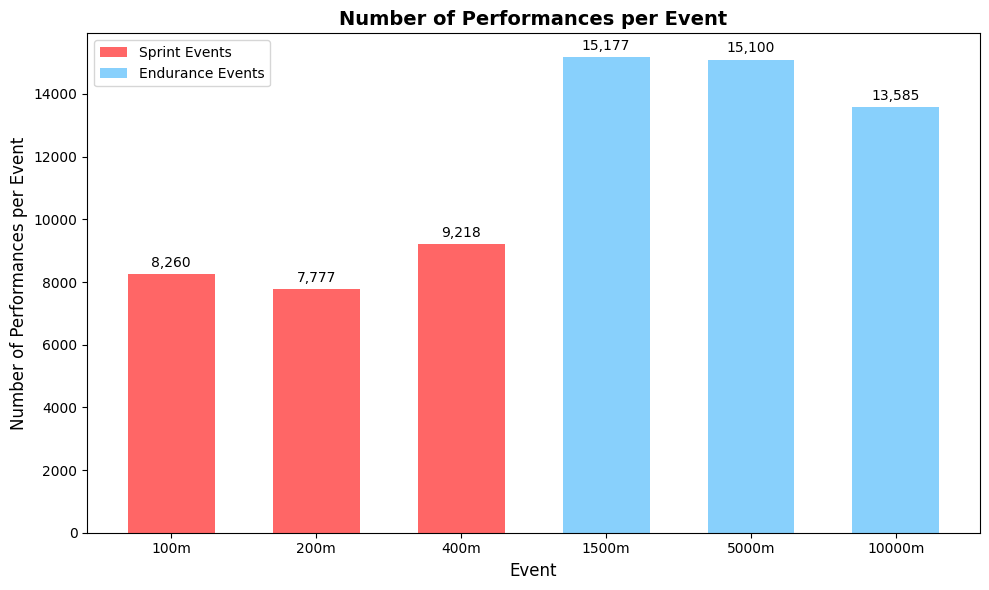

In [43]:
# To help visualise how much data I have per event, I'm going to create a bar chart.

event_counts = df_clean["Event"].value_counts()
event_counts = event_counts.reindex(event_order)

fig, ax = plt.subplots(figsize = (10, 6))
colours = ["#ff6666", "#ff6666", "#ff6666", "#88d0fc", "#88d0fc", "#88d0fc"]
bars = ax.bar(event_order, event_counts.values, width = 0.6, color = colours)
ax.bar_label(bars, fmt = "{:,.0f}", padding = 3)
ax.set_title("Number of Performances per Event", fontsize = 14, fontweight = "bold")
ax.set_xlabel("Event", fontsize = 12)
ax.set_ylabel("Number of Performances per Event", fontsize = 12)
legend_elements = [Patch(facecolor = "#ff6666", label = "Sprint Events"), Patch(facecolor = "#88d0fc", label = "Endurance Events")]
ax.legend(handles = legend_elements, loc = "upper left")
                    

plt.tight_layout()
plt.savefig("figures/event_counts.png", dpi = 150, bbox_inches = "tight")
plt.show()

In [44]:
# I'm also going to create a grouped bar chart showing number of performances per event per gender

gender_counts = df_clean.groupby(["Event", "Gender"]).size().unstack(fill_value = 0)
gender_counts = gender_counts.loc[event_order]

print(gender_counts)

Gender  Female   Male
Event                
100m      3410   4850
200m      2732   5045
400m      4119   5099
1500m     3501  11676
5000m     5531   9569
10000m    2665  10920


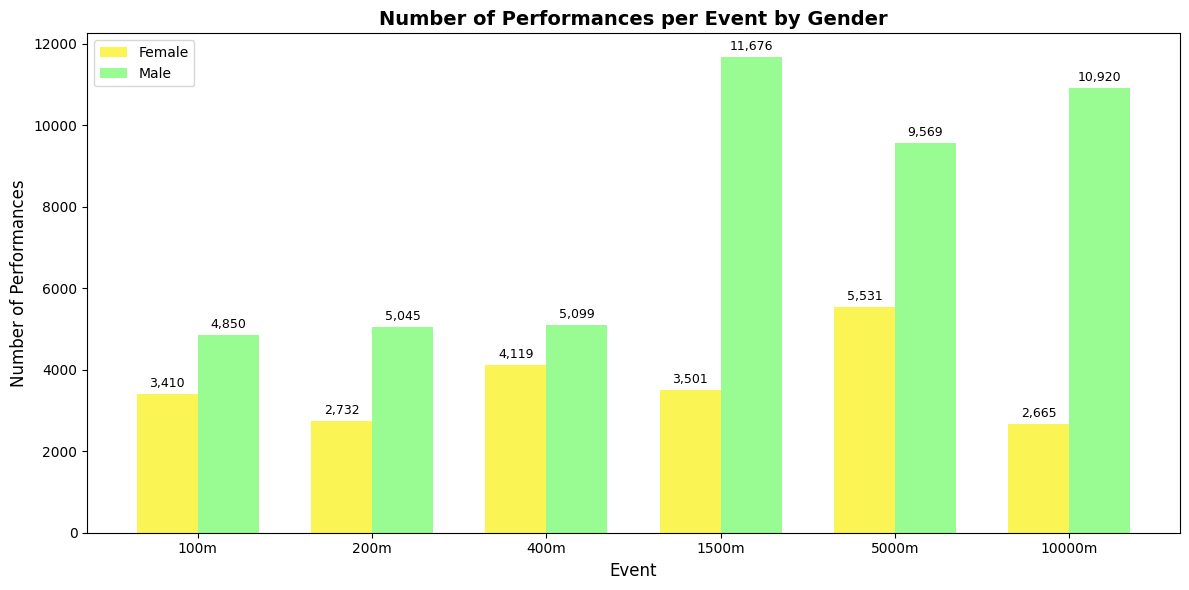

In [45]:
fig, ax = plt.subplots(figsize = (12, 6))

x = np.arange(len(event_order))
width = 0.35

bars_f = ax.bar(x - width/2, gender_counts["Female"], width, color = "#faf455", label = "Female")
bars_m = ax.bar(x + width/2, gender_counts["Male"], width, color = "#99fc92", label = "Male")
ax.bar_label(bars_f, fmt = "{:,.0f}", padding = 3, fontsize = 9)
ax.bar_label(bars_m, fmt = "{:,.0f}", padding = 3, fontsize = 9)

ax.set_xticks(x)
ax.set_xticklabels(event_order)

ax.set_title("Number of Performances per Event by Gender", fontsize = 14, fontweight = "bold")
ax.set_xlabel("Event", fontsize = 12)
ax.set_ylabel("Number of Performances", fontsize = 12)
ax.legend(loc = "upper left")

plt.tight_layout()
plt.savefig("figures/events_counts_by_gender.png", dpi = 150, bbox_inches = "tight")
plt.show()

### Performances per Year

I'm going to visualise how many recorded performances I have scraped per year to decide if there are any years with insufficient performances that need to be dropped.

In [46]:
# What years are available in the dataset?

year_counts = df_clean["Year"].value_counts()
year_counts

Year
2025    3909
2024    3805
2023    3362
2022    2991
2021    2666
        ... 
1964       8
1960       4
1958       2
1963       2
1962       1
Name: count, Length: 67, dtype: int64

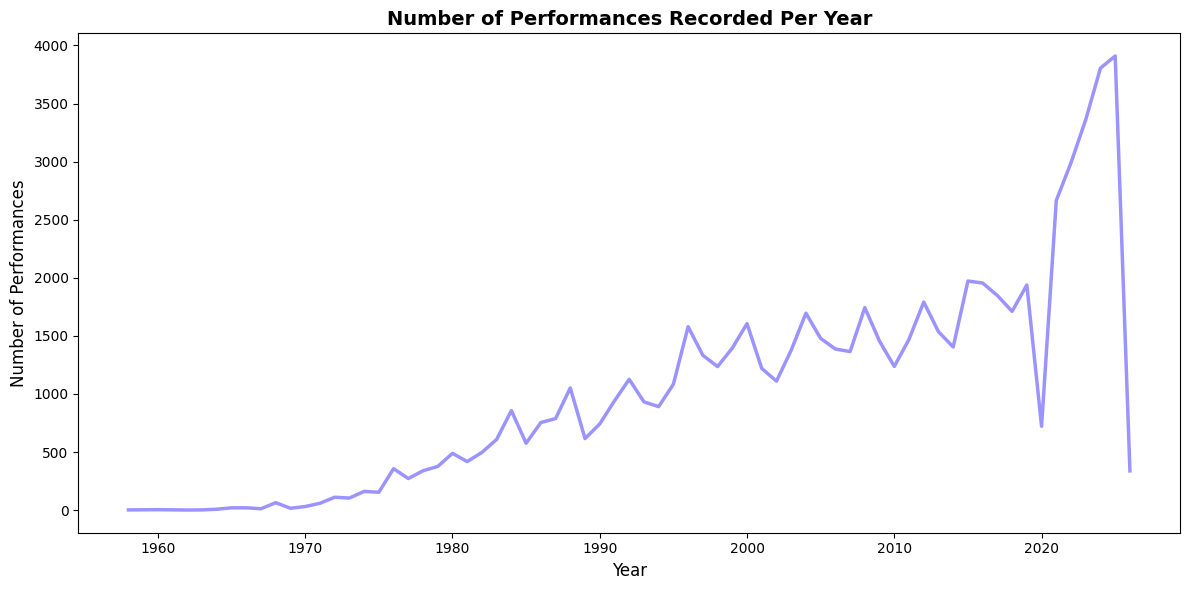

In [47]:
# Create a graph of how much data per year:

year_counts = df_clean.groupby("Year").size().reset_index(name = "Count")

fig, ax = plt.subplots(figsize = (12, 6))
ax.plot(year_counts["Year"], year_counts["Count"], color = "#9b94ff", linewidth = 2.5)
ax.set_title("Number of Performances Recorded Per Year", fontsize = 14, fontweight = "bold")
ax.set_xlabel("Year", fontsize = 12)
ax.set_ylabel("Number of Performances", fontsize = 12)

plt.tight_layout()
plt.savefig("figures/performances_per_year.png", dpi = 150, bbox_inches = "tight")
plt.show()

In [48]:
# What are the lower quartile, median and upper quartile of the year counts?

year_counts.quantile([0.25, 0.5, 0.75])

,Year,Count
0.25,1976.5,305.0
0.50,1993.0,932.0
0.75,2009.5,1474.5


In [49]:
# I'm going to work with the years that have at least 217 data points per year as 75% of the available years in the dataset have this number

year_counts[year_counts["Count"] < 217]

,Year,Count
0,1958,2
1,1960,4
2,1962,1
3,1963,2
4,1964,8
5,1965,20
6,1966,20
7,1967,12
8,1968,64
9,1969,16


I'll be dropping the years 1958-1975 as well as 2026 because there is not sufficient data points to provide quality analysis.

In [50]:
# Drop the years with insufficient data

years_to_drop = year_counts[year_counts["Count"] < 217]["Year"]
df_clean = df_clean[~df_clean["Year"].isin(years_to_drop)]

In [51]:
# Now what is the minimum count per year?

df_clean["Year"].value_counts().min()

np.int64(272)

In [52]:
# Checking 1961 has no data as it didn't appear in the years with less than 217 counts.

print(year_counts[year_counts["Year"] == 1961])

Empty DataFrame
Columns: [Year, Count]
Index: []


Years with performance counts below the 25th percentile were removed from the dataset. This is because using percentiles is a data-driven approach to excluding years with insufficient performance data for thorough comparison. This removed the first 16 years of data (1958-1975) and 2026. The 2026 season has not been completed at the time of data collection.

### Outliers

Investigating if there are any outliers within the dataset

In [53]:
# Investigate if there are any outliers

df_clean.groupby(["Event", "Gender"])["Time Seconds"].describe()

count         mean        std      min      25%       50%  \
Event  Gender                                                                
100m   Female   3407.0    10.991083   0.089710    10.54    10.94    11.010   
       Male     4840.0    10.015579   0.068899     9.58     9.98    10.040   
200m   Female   2718.0    22.348400   0.206637    21.34    22.23    22.400   
       Male     4997.0    20.202512   0.169286    19.19    20.12    20.250   
400m   Female   4108.0    50.408537   0.496099    47.60    50.14    50.530   
       Male     5050.0    44.837186   0.315343    43.03    44.68    44.930   
1500m  Female   3493.0   242.591437   1.784227   238.10   241.38   242.990   
       Male    11546.0   215.588752   1.993239   206.00   214.51   216.110   
5000m  Female   5531.0   906.016328  15.228911   838.06   897.20   909.800   
       Male     9416.0   798.413545   9.556707   755.36   793.06   800.975   
10000m Female   2665.0  1895.304852  30.484781  1734.14  1879.87  1903.600   
       Male    10577.0  1683.659974  22.395674  1571.00  1671.64  1689.470   

                    75%      max  
Event  Gender                     
100m   Female    11.060    11.09  
       Male      10.070    10.09  
200m   Female    22.510    22.59  
       Male      20.330    20.39  
400m   Female    50.790    50.99  
       Male      45.080    45.20  
1500m  Female   244.110   244.99  
       Male     217.150   217.99  
5000m  Female   918.435   924.99  
       Male     805.970   809.99  
10000m Female  1918.330  1929.99  
       Male    1701.310  1709.99

In [54]:
# How many outliers are there for each event in both genders?

for event in event_order:
    for gender in ["Female", "Male"]:
        event_data = df_clean[(df_clean["Event"] == event) & (df_clean["Gender"] == gender)]["Time Seconds"]
        if len(event_data) == 0:
            continue
            
        Q1 = event_data.quantile(0.25)
        Q3 = event_data.quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)

        outliers = event_data[(event_data < lower_bound) | (event_data > upper_bound)]

        print("{} {}: {} outliers (below {:.2f} or above {:.2f})".format(event, gender, len(outliers), lower_bound, upper_bound))

100m Female: 79 outliers (below 10.76 or above 11.24)
100m Male: 136 outliers (below 9.85 or above 10.21)
200m Female: 52 outliers (below 21.81 or above 22.93)
200m Male: 167 outliers (below 19.81 or above 20.64)
400m Female: 98 outliers (below 49.17 or above 51.77)
400m Male: 145 outliers (below 44.08 or above 45.68)
1500m Female: 0 outliers (below 237.28 or above 248.21)
1500m Male: 271 outliers (below 210.55 or above 221.11)
5000m Female: 70 outliers (below 865.35 or above 950.29)
5000m Male: 163 outliers (below 773.69 or above 825.34)
10000m Female: 75 outliers (below 1822.18 or above 1976.02)
10000m Male: 276 outliers (below 1627.14 or above 1745.81)


In [55]:
# Given the nature of the data, the outliers are likely to be exceptionally fast athletes or slower athletes

for event in event_order:
    for gender in ["Female", "Male"]:
        event_data = df_clean[(df_clean["Event"] == event) & (df_clean["Gender"] == gender)]["Time Seconds"]
            
        Q1 = event_data.quantile(0.25)
        Q3 = event_data.quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)

        too_fast = event_data[event_data < lower_bound]
        too_slow = event_data[event_data > upper_bound]

        print("{} {}: {} suspiciously fast performances, {} slower performances".format(event, gender, len(too_fast), len(too_slow)))

100m Female: 79 suspiciously fast performances, 0 slower performances
100m Male: 136 suspiciously fast performances, 0 slower performances
200m Female: 52 suspiciously fast performances, 0 slower performances
200m Male: 167 suspiciously fast performances, 0 slower performances
400m Female: 98 suspiciously fast performances, 0 slower performances
400m Male: 145 suspiciously fast performances, 0 slower performances
1500m Female: 0 suspiciously fast performances, 0 slower performances
1500m Male: 271 suspiciously fast performances, 0 slower performances
5000m Female: 70 suspiciously fast performances, 0 slower performances
5000m Male: 163 suspiciously fast performances, 0 slower performances
10000m Female: 75 suspiciously fast performances, 0 slower performances
10000m Male: 276 suspiciously fast performances, 0 slower performances


**Outlier analysis:**  
All of the outliers within my data are below the lower bound. I'm not going to remove these given the nature of my dataset. My dataset contains the all-time best athletics performances so is naturally going to be heavily skewed towards the faster times. The best performances (world records or near world records) are exceptional and are always going to fall below the lower bound, but they are not data errors. Removing these outliers would risk discarding the most significant data in my dataset.

In [56]:
# What does the dataset look like now that I've cleaned it

df_clean = df_clean.reset_index(drop = True)
df_clean.head()

,Rank,Time,Athlete,Year,Event,Gender,Time Seconds
0,1569,11.01,Annegret Richter,1976,100m,Female,11.01
1,2058,11.04,Ingeborg Helten,1976,100m,Female,11.04
2,2242,11.05,Annegret Richter,1976,100m,Female,11.05
3,2419,11.06,Annegret Richter,1976,100m,Female,11.06
4,2906,11.08,Brenda Morehead,1976,100m,Female,11.08


In [57]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 68348 entries, 0 to 68347
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Rank          68348 non-null  int64   
 1   Time          68348 non-null  str     
 2   Athlete       68348 non-null  str     
 3   Year          68348 non-null  int64   
 4   Event         68348 non-null  category
 5   Gender        68348 non-null  str     
 6   Time Seconds  68348 non-null  float64 
dtypes: category(1), float64(1), int64(2), str(3)
memory usage: 3.2 MB


In [58]:
# Save the cleaned data to a CSV

df_clean.to_csv("data/processed/athletics_clean.csv", index = False)
print("Saved cleaned data!")

Saved cleaned data!


## Data analysis

In [59]:
# Load the cleaned data CSV
df_clean = pd.read_csv("data/processed/athletics_clean.csv")
df_clean.info()

# Create a copy of the original DataFrame
df_analysis = df_clean.copy()

<class 'pandas.DataFrame'>
RangeIndex: 68348 entries, 0 to 68347
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          68348 non-null  int64  
 1   Time          68348 non-null  str    
 2   Athlete       68348 non-null  str    
 3   Year          68348 non-null  int64  
 4   Event         68348 non-null  str    
 5   Gender        68348 non-null  str    
 6   Time Seconds  68348 non-null  float64
dtypes: float64(1), int64(2), str(4)
memory usage: 3.7 MB


In [60]:
# Order events again

df_analysis["Event"] = pd.Categorical(df_analysis["Event"], categories = event_order, ordered = True)
df_analysis.sort_values(by = ["Gender", "Event", "Year"], ascending = [True, True, True], inplace = True)

### Exploring trends

#### Trends across time

I'm going to begin the data analysis by exploring trends across time in each event for both men and women.

In [61]:
# Gather the minimum (fastest) time per event in each year for both men and women

min_times = (df_analysis.groupby(["Event", "Gender", "Year"])["Time Seconds"].min().reset_index())
min_times.head()

,Event,Gender,Year,Time Seconds
0,100m,Female,1976,11.01
1,100m,Female,1977,10.88
2,100m,Female,1978,10.94
3,100m,Female,1979,10.97
4,100m,Female,1980,10.93


I've used the fastest time from each year rather than the average (for example) because it directly reflects the progression of athletic performance, which is the focus of my analysis. Average time is influenced by participation rates. Also, my dataset contains the all-time best performances, so the average of my dataset does not represent the average athlete.

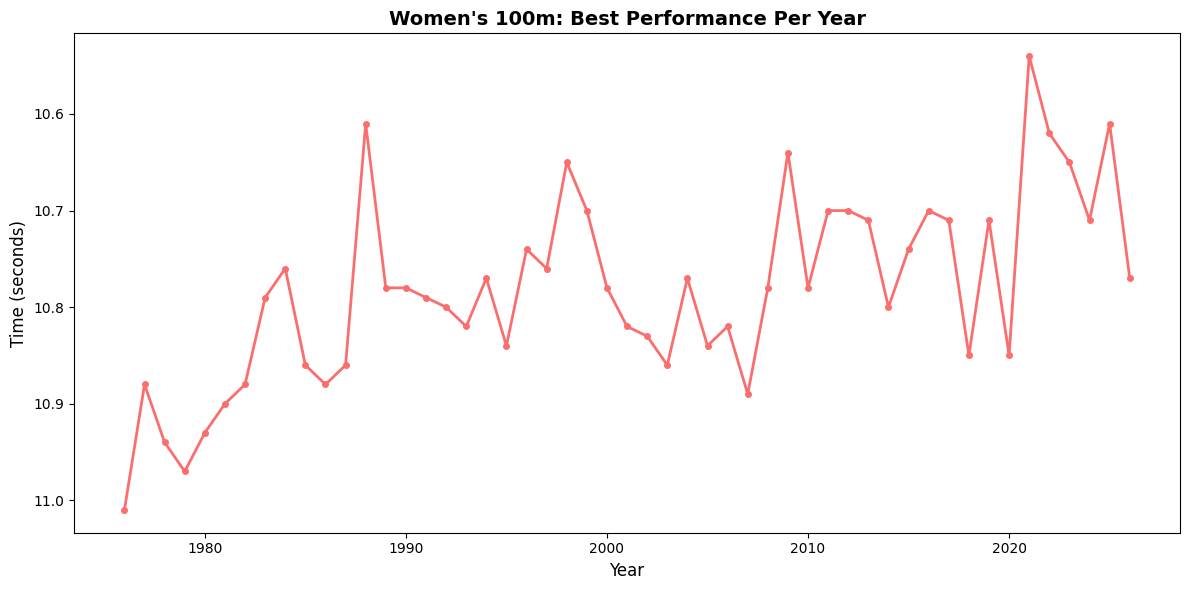

In [62]:
# Test plotting by only plotting female 100m performances against time

df_100m_f = min_times[(min_times["Event"] == "100m") & (min_times["Gender"] == "Female")]

fig, ax = plt.subplots(figsize = (12, 6))

ax.plot(df_100m_f["Year"], df_100m_f["Time Seconds"], color = "#fa6e6e", linewidth = 2, marker = "o", markersize = 4)
ax.set_title("Women's 100m: Best Performance Per Year", fontsize = 14, fontweight = "bold")
ax.set_xlabel("Year", fontsize = 12)
ax.set_ylabel("Time (seconds)", fontsize = 12)
# Invert the y-axis so faster times appear higher on the plot, more intuitive to look at as faster time = better
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("figures/100mW_progression.png", dpi = 150, bbox_inches = "tight")
plt.show()

There is a problem when I attempt to plot female performances from all events onto one plot: time scale. 100m is approximately 11 seconds compared to 10,000m at approximately 1900 seconds. All events will not be readable on the same y-axis.  
A solution is to calculate percentage improvement in each event compared to the first year.

In [63]:
# Calculate percentage improvement in each event relative to the first year

min_times_pct = min_times.copy()

for event in min_times_pct["Event"].unique():
    for gender in min_times_pct["Gender"].unique():
        mins = (min_times_pct["Event"] == event) & (min_times_pct["Gender"] == gender)
        if mins.sum() == 0:
            continue
        baseline = min_times_pct[mins]["Time Seconds"].iloc[0]
        min_times_pct.loc[mins, "Percentage Improvement"] = ((baseline - min_times_pct.loc[mins, "Time Seconds"]) / baseline * 100)

min_times_pct

,Event,Gender,Year,Time Seconds,Percentage Improvement
0,100m,Female,1976,11.01,0.000000
1,100m,Female,1977,10.88,1.180745
2,100m,Female,1978,10.94,0.635786
3,100m,Female,1979,10.97,0.363306
4,100m,Female,1980,10.93,0.726612
...,...,...,...,...,...
594,10000m,Male,2022,1593.84,4.007516
595,10000m,Male,2023,1610.66,2.994495
596,10000m,Male,2024,1591.01,4.177959
597,10000m,Male,2025,1603.82,3.406449


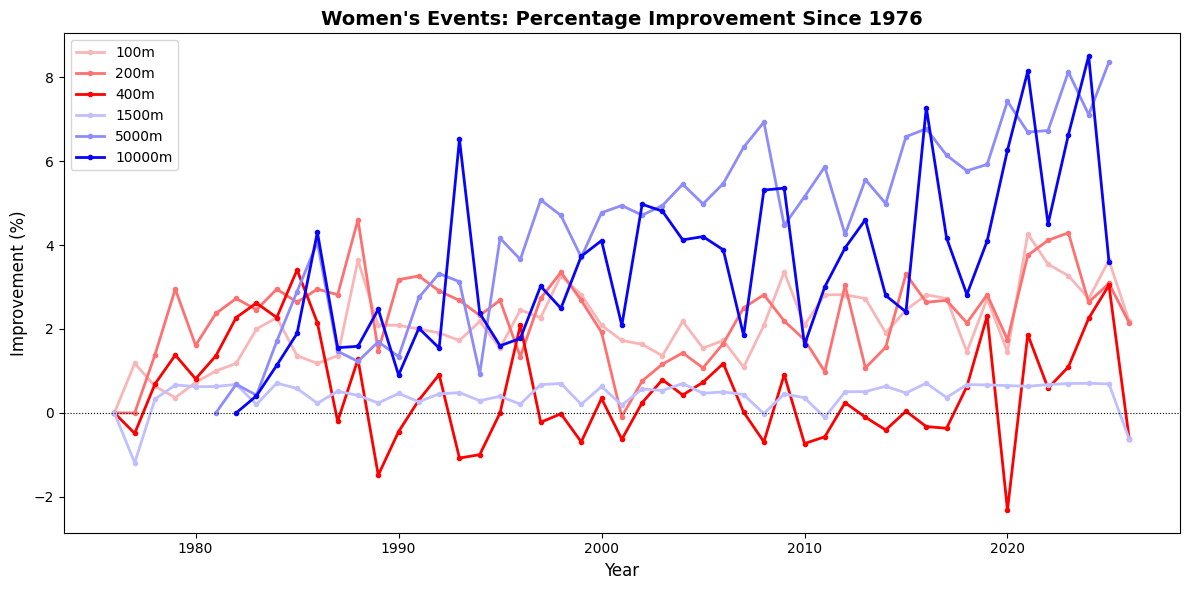

In [64]:
# Plot percentage change in female performance in all events across time.

female_data = min_times_pct[min_times_pct["Gender"] == "Female"]
colours1 = {"100m": "#fab6b6", "200m": "#ff7070", "400m": "#ff0000", 
            "1500m": "#c0bfff", "5000m": "#8e8cfa", "10000m": "#0703fc"}

fig, ax = plt.subplots(figsize = (12, 6))

for event in female_data["Event"].unique():
    event_data = female_data[female_data["Event"] == event]
    ax.plot(event_data["Year"], event_data["Percentage Improvement"], 
            color = colours1[event], linewidth = 2, marker = "o", 
            markersize = 3, label = event)

ax.set_title("Women's Events: Percentage Improvement Since 1976", fontsize = 14, fontweight = "bold")
ax.set_xlabel("Year", fontsize = 12)
ax.set_ylabel("Improvement (%)", fontsize = 12)
ax.legend(loc = "upper left")
ax.axhline(0, color = "black", linewidth = 0.8, linestyle = ":")

plt.tight_layout()
plt.savefig("figures/female_events_pct_improvement.png", dpi = 150, bbox_inches = "tight")
plt.show()

In [65]:
# Assign each event an event type

sprint_events = ["100m", "200m", "400m"]
endurance_events = ["1500m", "5000m", "10000m"]

def assign_event_type(event):
    if event in sprint_events:
        return "Sprint"
    else:
        return "Endurance"

min_times_pct["Event Type"] = min_times_pct["Event"].apply(assign_event_type)

min_times_pct

,Event,Gender,Year,Time Seconds,Percentage Improvement,Event Type
0,100m,Female,1976,11.01,0.000000,Sprint
1,100m,Female,1977,10.88,1.180745,Sprint
2,100m,Female,1978,10.94,0.635786,Sprint
3,100m,Female,1979,10.97,0.363306,Sprint
4,100m,Female,1980,10.93,0.726612,Sprint
...,...,...,...,...,...,...
594,10000m,Male,2022,1593.84,4.007516,Endurance
595,10000m,Male,2023,1610.66,2.994495,Endurance
596,10000m,Male,2024,1591.01,4.177959,Endurance
597,10000m,Male,2025,1603.82,3.406449,Endurance


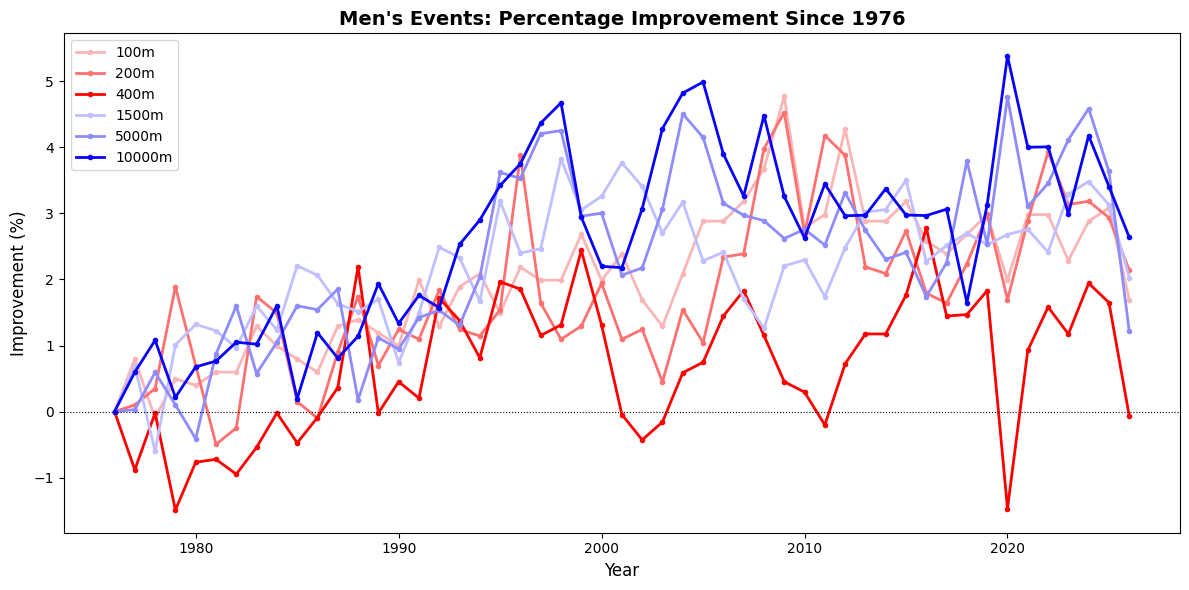

In [66]:
# Plot percentage change in male performance in all events across time.

male_data = min_times_pct[min_times_pct["Gender"] == "Male"]
colours1 = {"100m": "#fab6b6", "200m": "#ff7070", "400m": "#ff0000", 
            "1500m": "#c0bfff", "5000m": "#8e8cfa", "10000m": "#0703fc"}

fig, ax = plt.subplots(figsize = (12, 6))

for event in male_data["Event"].unique():
    event_data = male_data[male_data["Event"] == event]
    ax.plot(event_data["Year"], event_data["Percentage Improvement"], 
            color = colours1[event], linewidth = 2, marker = "o", 
            markersize = 3, label = event)

ax.set_title("Men's Events: Percentage Improvement Since 1976", fontsize = 14, fontweight = "bold")
ax.set_xlabel("Year", fontsize = 12)
ax.set_ylabel("Improvement (%)", fontsize = 12)
ax.legend(loc = "upper left")
ax.axhline(0, color = "black", linewidth = 0.8, linestyle = ":")

plt.tight_layout()
plt.savefig("figures/male_events_pct_improvement.png", dpi = 150, bbox_inches = "tight")
plt.show()

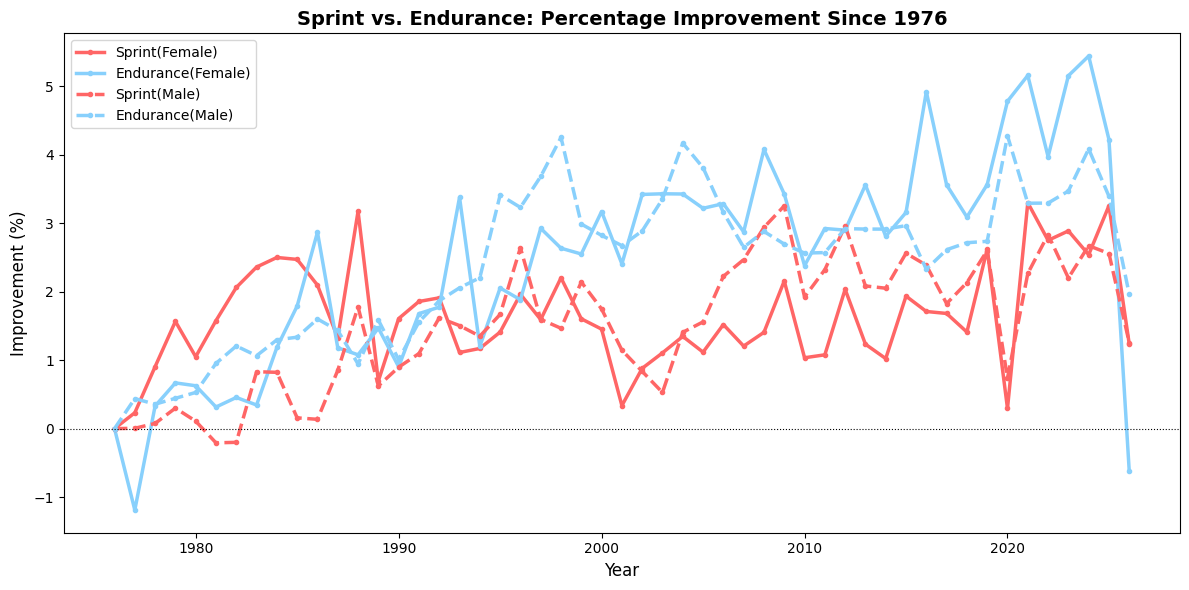

In [67]:
# Combine female and male percentage change in performance onto one figure
# I'm going to combine events into sprint and endurance rather than plot each individual event otherwise the graph would be too crowded

fig, ax = plt.subplots(figsize = (12, 6))

line_styles = {"Female": "-", "Male": "--"}
colours2 = {"Sprint": "#ff6666", "Endurance": "#88d0fc"}

for gender in ["Female", "Male"]:
    grouped = (min_times_pct[min_times_pct["Gender"] == gender]
        .groupby(["Event Type", "Year"])["Percentage Improvement"].mean().reset_index())
    for event_type in ["Sprint", "Endurance"]:
        event_data = grouped[grouped["Event Type"] == event_type]
        ax.plot(event_data["Year"], event_data["Percentage Improvement"], 
                color = colours2[event_type], linestyle = line_styles[gender], linewidth = 2.5, 
                marker = "o", markersize = 3, label = event_type + "("+ gender +")")

ax.set_title("Sprint vs. Endurance: Percentage Improvement Since 1976", 
             fontsize = 14, fontweight = "bold")
ax.set_xlabel("Year", fontsize = 12)
ax.set_ylabel("Improvement (%)", fontsize = 12)
ax.legend(loc = "upper left")
ax.axhline(0, color = "black", linewidth = 0.8, linestyle = ":")

plt.tight_layout()
plt.savefig("figures/combined_improvement.png", dpi = 150, bbox_inches = "tight")
plt.show()

The plots I've made so far show me the trends over time and the differences between sprint and endurance, but in a visual way. Now I'll run regression analysis to quantify the trends I've visually observed.

### Regression Analysis

#### Linear Regression

First I'll run a linear regression of percentage change in time against year.

In [68]:
regression_results = []

for gender in ["Female", "Male"]:
    for event_type in ["Sprint", "Endurance"]:
        filtering = ((min_times_pct["Gender"] == gender) & 
                     (min_times_pct["Event Type"] == event_type))
        data =(min_times_pct[filtering]
            .groupby("Year")["Percentage Improvement"].mean().reset_index())
        slope, intercept, r_value, p_value, std_err = stats.linregress(data["Year"], data["Percentage Improvement"])
        regression_results.append({"Gender": gender, "Event Type": event_type, "Slope": round(slope, 4), 
                                   "Intercept": round(intercept, 4), "R^2": round(r_value**2, 3), 
                                   "P value": round(p_value, 4), "Standard error": round(std_err, 4)})

df_regression = pd.DataFrame(regression_results)
df_regression

,Gender,Event Type,Slope,Intercept,R^2,P value,Standard error
0,Female,Sprint,0.0137,-25.7027,0.071,0.0596,0.0071
1,Female,Endurance,0.0798,-157.2119,0.586,0.0000,0.0096
2,Male,Sprint,0.0488,-96.1082,0.581,0.0000,0.0059
3,Male,Endurance,0.0567,-111.1551,0.570,0.0000,0.0070


**Key findings**  
Female sprinting:
* slope = 0.014: improving at a very slow rate of 0.014% per year
* R^2 = 0.071: the regression line only explains 7.1% of the variation in female sprinting data which is a very weak fit
* p-value = 0.06: the test is statistically significant

Female endurance:
* slope = 0.12: the rate of improvement is must faster than female sprinting at 0.12% per year
* R^2 = 0.75: the regression line explains 75% of the variation in the data
* p-value = 0: highly statistically significant
  
Male sprinting:
* slope = 0.05: moderate improvement at 0.05% per year
* R^2 = 0.63: the regression explains 63% of the variation in the data
* p-value = 0: highly statistically significant

Male endurance:
* slope = 0.06: slightly higher but very similar to male sprinting at 0.06% per year
* R^2 = 0.63: almost identical to male sprinting
* p-value: highly statistically significant


#### Grouped regression analysis

I'm going to split the data into two timeframes to investigate whether the rate of improvement has slowed. I'm going to split the data into pre-2000 and post-2000 as this is the mid-point of my dataset.

In [69]:
split_year = 2000
split_results = []

# filter to one gender and event type
gender = "Female"
event_type = "Sprint"

filtering1 = ((min_times_pct["Gender"] == gender) & (min_times_pct["Event Type"] == event_type))
data1 = (min_times_pct[filtering1].groupby("Year")["Percentage Improvement"].mean().reset_index())

print("Filtered Data")
print(data1.head())
print("Rows: " + str(len(data1)))

Filtered Data
   Year  Percentage Improvement
0  1976                0.000000
1  1977                0.231244
2  1978                0.903835
3  1979                1.564519
4  1980                1.049200
Rows: 51


In [70]:
# split the data into two periods

early = data1[data1["Year"] < split_year]
modern = data1[data1["Year"] >= split_year]

print("Pre-2000 rows:  " + str(len(early)))
print("Post-2000 rows: " + str(len(modern)))

Pre-2000 rows:  24
Post-2000 rows: 27


In [71]:
# Regression of early period

slope_early, intercept_early, r_early, p_early, std_early = stats.linregress(early["Year"], early["Percentage Improvement"])

print("Pre-2000 regression:")
print("Slope: " + str(round(slope_early, 4)))
print("Intercept: " + str(round(intercept_early, 4)))
print("R^2: " + str(round(r_early**2, 3)))
print("P-value: " + str(round(p_early, 4)))

Pre-2000 regression:
Slope: 0.0315
Intercept: -61.0344
R^2: 0.093
P-value: 0.1476


In [72]:
# Regression modern period

slope_modern, intercept_modern, r_modern, p_modern, std_modern = stats.linregress(modern["Year"], modern["Percentage Improvement"])

print("Post-2000 regression:")
print("Slope: " + str(round(slope_modern, 4)))
print("Intercept: " + str(round(intercept_modern, 4)))
print("R^2: " + str(round(r_modern**2, 3)))
print("P-value: " + str(round(p_modern, 4)))

Post-2000 regression:
Slope: 0.0605
Intercept: -120.0667
R^2: 0.355
P-value: 0.001


In [73]:
# Comparing the slopes to see whether improvement rate has increased or decreased.

print("Pre-2000 slope: " + str(round(slope_early, 4)))
print("Post-2000 slope: " + str(round(slope_modern, 4)))

Pre-2000 slope: 0.0315
Post-2000 slope: 0.0605


We can see improvement has accelerated across the time period in female sprinting. This is contrary to what I expected. Possible reasons for this include increased global participation and an improvement in womens' athletics as a whole.

In [74]:
# Create a loop to print the results for both genders and event type

split_year = 2000

for gender in ["Female", "Male"]:
    for event_type in ["Sprint", "Endurance"]:
        filtering2 = ((min_times_pct["Gender"] == gender) & (min_times_pct["Event Type"] == event_type))
        data2 = ((min_times_pct[filtering2].groupby("Year")["Percentage Improvement"].mean().reset_index()))

        early = data2[data2["Year"] < split_year]
        modern = data2[data2["Year"] >= split_year]

        slope_early, intercept_early, r_early, p_early, std_early = stats.linregress(early["Year"], early["Percentage Improvement"])
        slope_modern, intercept_modern, r_modern, p_modern, std_modern = stats.linregress(modern["Year"], modern["Percentage Improvement"])

        print(gender + " " + event_type + ":")
        print("Pre-2000 slope: " + str(round(slope_early, 4)) + "(p = " + str(round(p_early, 4)) + ")")
        print("Post-2000 slope: " + str(round(slope_modern, 4)) + "(p = " + str(round(p_modern, 4)) + ")")

        if abs(slope_modern) < abs(slope_early):
            print("Improvement has slowed")
        else:
            print("Improvement has accelerated")
        print()

Female Sprint:
Pre-2000 slope: 0.0315(p = 0.1476)
Post-2000 slope: 0.0605(p = 0.001)
Improvement has accelerated

Female Endurance:
Pre-2000 slope: 0.1224(p = 0.0)
Post-2000 slope: 0.0308(p = 0.2944)
Improvement has slowed

Male Sprint:
Pre-2000 slope: 0.0982(p = 0.0)
Post-2000 slope: 0.029(p = 0.0989)
Improvement has slowed

Male Endurance:
Pre-2000 slope: 0.1456(p = 0.0)
Post-2000 slope: 0.0043(p = 0.7621)
Improvement has slowed



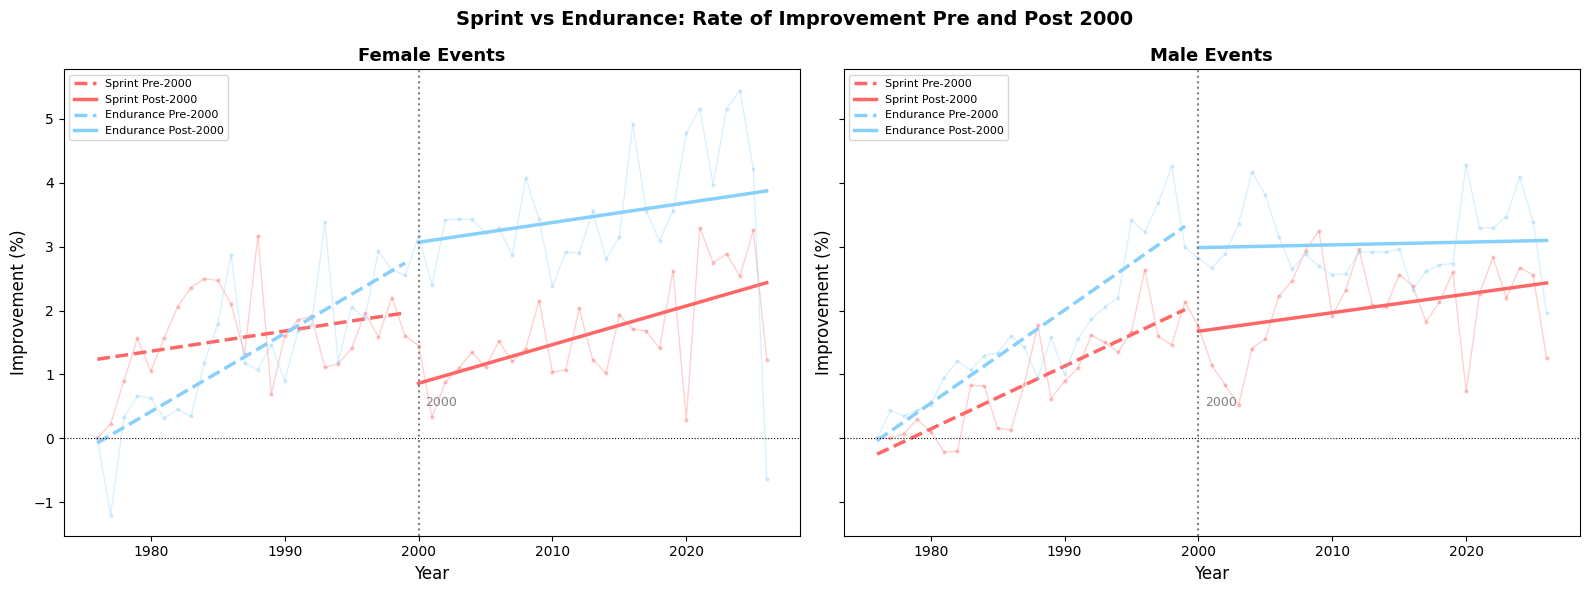

In [77]:
# Plot the regression lines onto the graph of percentage improvement

fig, axes = plt.subplots(1, 2, figsize = (16, 6), sharey = True)

for ax, gender in zip(axes, ["Female", "Male"]):
    for event_type, colour in [("Sprint", "#ff6666"), ("Endurance", "#88d0fc")]:
        filtering2 = ((min_times_pct["Gender"] == gender) & (min_times_pct["Event Type"] == event_type))
        data2 = (min_times_pct[filtering2].groupby("Year")["Percentage Improvement"].mean().reset_index())

        # Plot the raw data
        ax.plot(data2["Year"], data2["Percentage Improvement"], color = colour, linewidth = 1, alpha = 0.3, marker = "o", markersize = 2)

        # Plot the regression line for each period
        for period, linestyle, label in [(data2[data2["Year"] < split_year], "--", "Pre-2000"), 
                                         (data2[data2["Year"] >= split_year], "-", "Post-2000")]:
            slope, intercept, _, _, _ = stats.linregress(period["Year"], period["Percentage Improvement"])
            x = np.array([period["Year"].min(), period["Year"].max()])
            ax.plot(x, slope * x + intercept, color = colour, linewidth = 2.5, linestyle = linestyle, label = event_type + " " + label)
            
    ax.axvline(x = split_year, color = "gray", linestyle = ":", linewidth = 1.5)
    ax.text(2000.5, 0.5, "2000", fontsize = 9, color = "gray")
    ax.set_title(gender + " Events", fontsize = 13, fontweight = "bold")
    ax.set_xlabel("Year", fontsize = 12)
    ax.set_ylabel("Improvement (%)", fontsize = 12)
    ax.legend(loc = "upper left", fontsize = 8)
    ax.axhline(0, color = "black", linewidth = 0.8, linestyle = ":")

plt.suptitle("Sprint vs Endurance: Rate of Improvement Pre and Post 2000", fontsize = 14, fontweight = "bold")
plt.tight_layout()
plt.savefig("figures/split_regression.png", dpi = 150, bbox_inches = "tight")
plt.show()
              